## HW01-ICA :: Part B
### Adam Nelson-Archer, 2140122

All paths are relative to this notebook location (`Part B/`).


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
except ImportError as e:
    raise ImportError("OpenCV (cv2) is not installed in this environment.") from e

print("cv2 version:", cv2.__version__)


cv2 version: 4.10.0


(a) Load image (BGR), convert to RGB, plot with Matplotlib


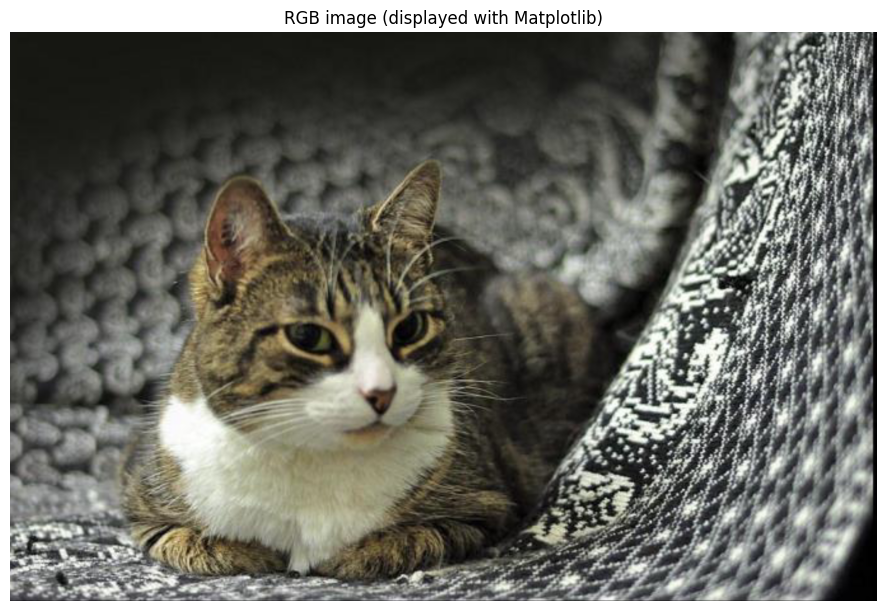

In [2]:
# Image is located in Part A.
img_path = Path("..") / "Part A" / "cat.png"

if not img_path.exists():
    raise FileNotFoundError(f"Could not find image at: {img_path.resolve()}")

# OpenCV reads color images as BGR by default
bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if bgr is None:
    raise ValueError("cv2.imread returned None. The file may be unreadable or corrupted.")

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(9, 6), constrained_layout=True)
ax.imshow(rgb)
ax.set_title("RGB image (displayed with Matplotlib)")
ax.axis("off")
plt.show()


(b) Print pixels, height, width, channels (color image)


In [3]:
h, w, c = bgr.shape
num_pixels = h * w

print("Loaded:", img_path)
print("Number of pixels:", num_pixels)
print("Height:", h)
print("Width:", w)
print("Channels:", c)


Loaded: ..\Part A\cat.png
Number of pixels: 1762488
Height: 1076
Width: 1638
Channels: 3


(c) Isolate Red, Green, Blue channels and plot them


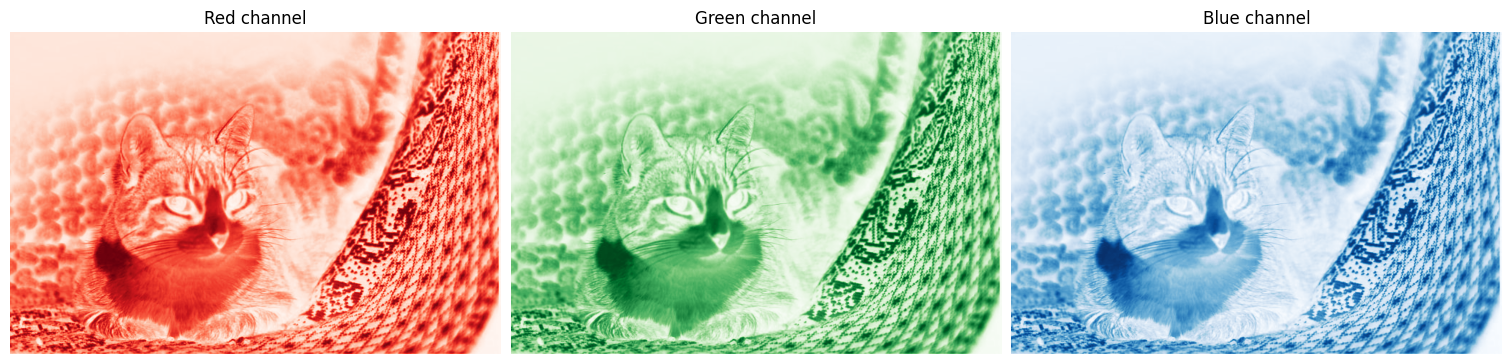

In [4]:
# rgb is HxWx3 with channels ordered [R, G, B]
r = rgb[:, :, 0]
g = rgb[:, :, 1]
b = rgb[:, :, 2]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ax[0].imshow(r, cmap="Reds")
ax[0].set_title("Red channel")
ax[0].axis("off")

ax[1].imshow(g, cmap="Greens")
ax[1].set_title("Green channel")
ax[1].axis("off")

ax[2].imshow(b, cmap="Blues")
ax[2].set_title("Blue channel")
ax[2].axis("off")

plt.show()


(d) Compute and plot unnormalized histograms for R, G, B channels


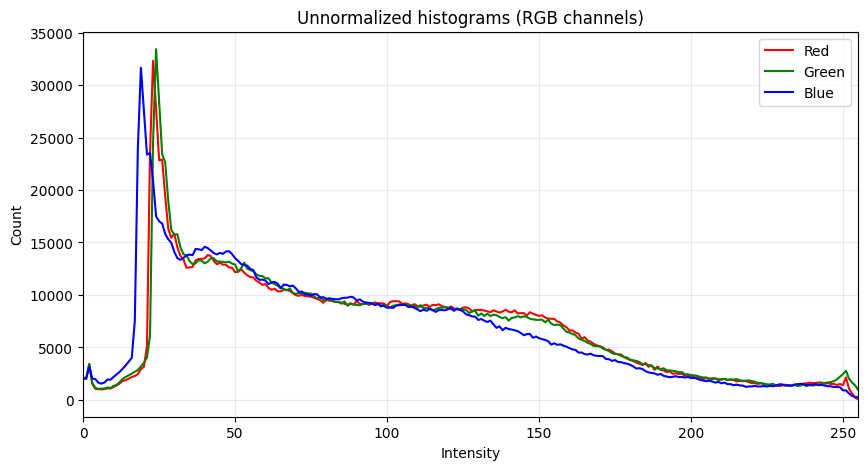

In [5]:
# Unnormalized histogram: raw counts per intensity bin
hist_r = cv2.calcHist([r], [0], None, [256], [0, 256]).ravel()
hist_g = cv2.calcHist([g], [0], None, [256], [0, 256]).ravel()
hist_b = cv2.calcHist([b], [0], None, [256], [0, 256]).ravel()

x = np.arange(256)

plt.figure(figsize=(10, 5))
plt.plot(x, hist_r, color="red", label="Red")
plt.plot(x, hist_g, color="green", label="Green")
plt.plot(x, hist_b, color="blue", label="Blue")
plt.title("Unnormalized histograms (RGB channels)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


(e) Convert to grayscale and plot


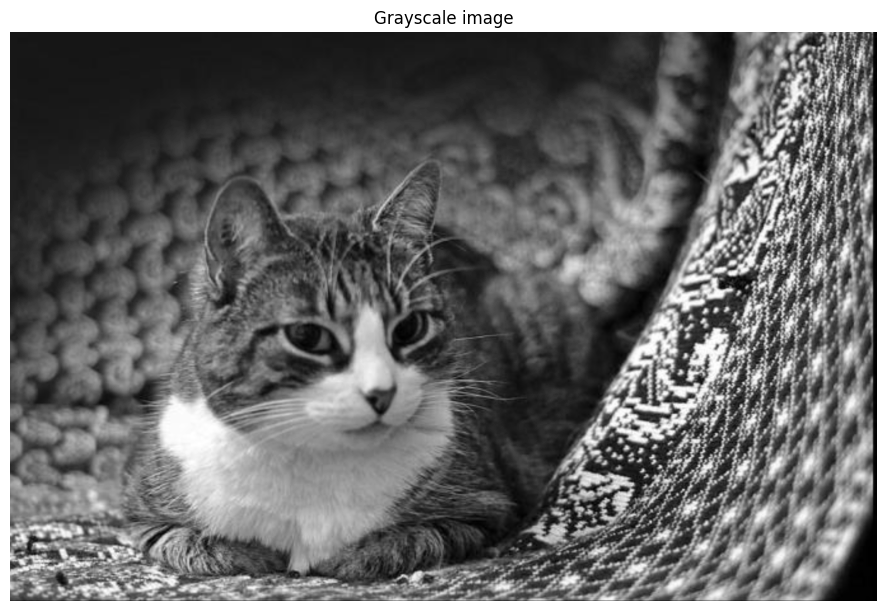

In [6]:
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 1, figsize=(9, 6), constrained_layout=True)
ax.imshow(gray, cmap="gray")
ax.set_title("Grayscale image")
ax.axis("off")
plt.show()


## (f) Print pixels, height, width, channels (grayscale image)


In [7]:
h_g, w_g = gray.shape
num_pixels_g = h_g * w_g
channels_g = 1

print("Number of pixels:", num_pixels_g)
print("Height:", h_g)
print("Width:", w_g)
print("Channels:", channels_g)


Number of pixels: 1762488
Height: 1076
Width: 1638
Channels: 1


(g) Compute and plot unnormalized histogram (grayscale)


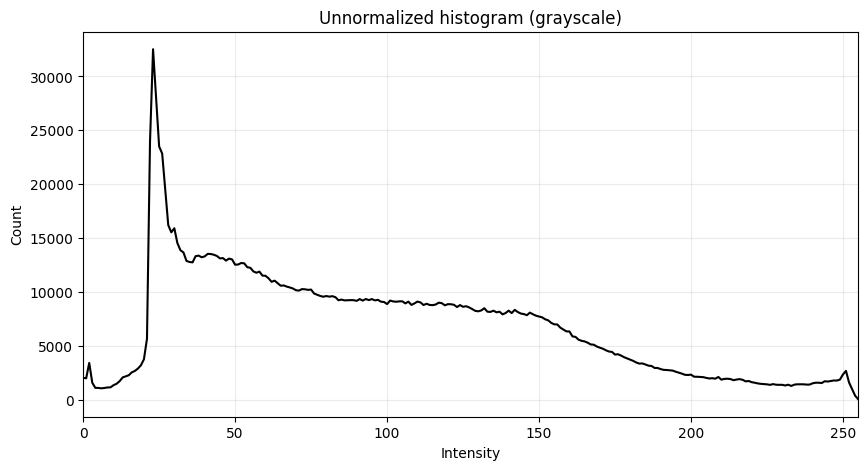

In [8]:
hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()

x = np.arange(256)
plt.figure(figsize=(10, 5))
plt.plot(x, hist_gray, color="black")
plt.title("Unnormalized histogram (grayscale)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.grid(alpha=0.25)
plt.show()


(h) Apply a binary threshold and plot


Threshold value used: 128
Unique values in thresholded image: [  0 255]


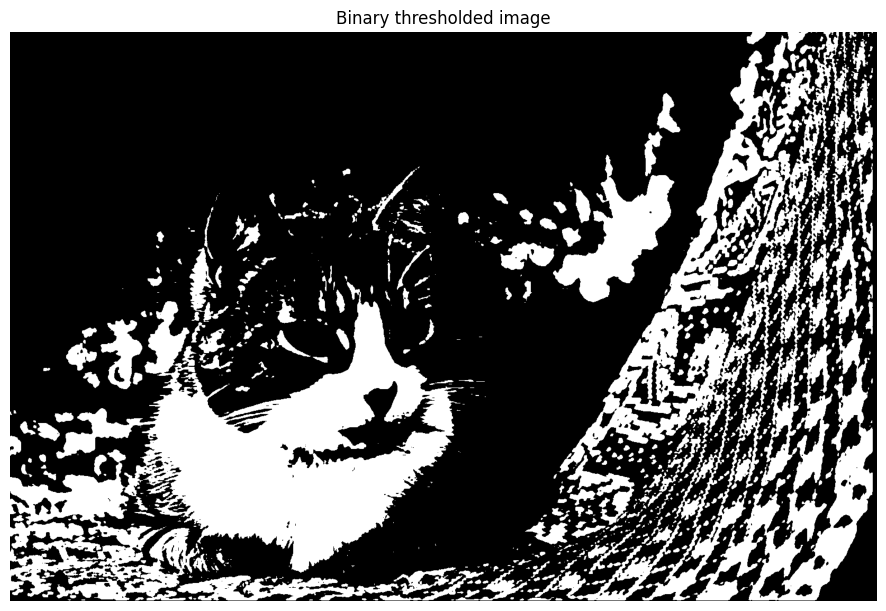

In [9]:
# You can adjust this threshold value if you want.
threshold_value = 128
_, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

print("Threshold value used:", threshold_value)
print("Unique values in thresholded image:", np.unique(thresh))

fig, ax = plt.subplots(1, 1, figsize=(9, 6), constrained_layout=True)
ax.imshow(thresh, cmap="gray")
ax.set_title("Binary thresholded image")
ax.axis("off")
plt.show()


(i) Compute and plot unnormalized histogram (thresholded image)


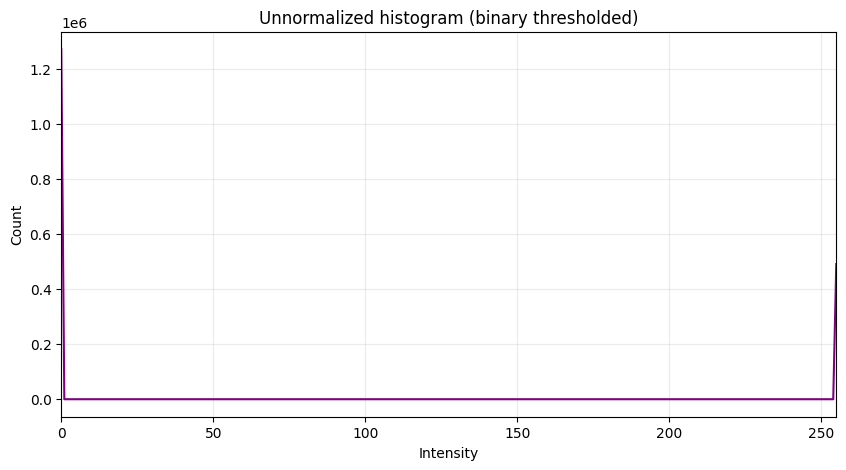

In [10]:
hist_thresh = cv2.calcHist([thresh], [0], None, [256], [0, 256]).ravel()

x = np.arange(256)
plt.figure(figsize=(10, 5))
plt.plot(x, hist_thresh, color="purple")
plt.title("Unnormalized histogram (binary thresholded)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.grid(alpha=0.25)
plt.show()


(j) Commentary

Answer the following:

1. What are the differences you observe in the histograms for the different color channels?

2. Converting an image to grayscale is the same operation as isolating a color channel? Yes/No and why?

3. What are the differences you observe in the histograms for the grayscale image and the thresholded image?